In [ ]:
!pip install torch torchvision numpy pandas matplotlib scikit-learn Pillow

Total images: 107730
Shape: (107730, 1, 28, 28)
Min: 0.00  Max: 1.00


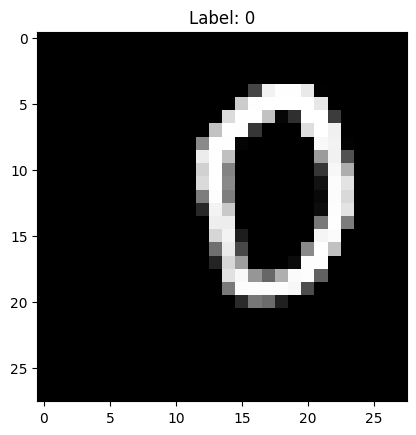

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# ── Load images ──────────────────────────────────────────────
DATASET_PATH = r"C:\Users\bilsr\OneDrive\Desktop\New folder\archive\dataset"
IMG_SIZE     = 28

images, labels = [], []

for label in range(10):
    folder = os.path.join(DATASET_PATH, str(label), str(label))
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath).convert('RGBA')
            # Extract the alpha channel — this is where the digit actually is
            alpha = np.array(img)[:, :, 3]
            alpha = alpha.astype(np.float32) / 255.0
            images.append(alpha.reshape(1, 28, 28))   # shape (1, 28, 28)
            labels.append(label)
        except:
            pass

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int64)

print(f"Total images: {len(X)}")
print(f"Shape: {X.shape}")
print(f"Min: {X.min():.2f}  Max: {X.max():.2f}")

# Verify it looks correct now
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()

In [56]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),   # padding=1 keeps size
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # 28x28 → 14x14

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                    # 14x14 → 7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),        # 7x7 because of padding
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# Verify output shape is correct
test_input = torch.randn(1, 1, 28, 28)
test_output = CNN()(test_input)
print("Output shape:", test_output.shape)  # should be torch.Size([1, 10])

print("CNN model defined ✓")

Output shape: torch.Size([1, 10])
CNN model defined ✓


In [57]:
NUM_RUNS = 5
SEEDS    = [42, 7, 99, 2024, 13]
results  = []
EPOCHS   = 10
BATCH    = 64

for run, seed in enumerate(SEEDS, 1):
    print(f"\n{'='*50}  RUN {run}  [seed={seed}]")

    torch.manual_seed(seed)
    np.random.seed(seed)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # DataLoaders with correct dtypes
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )
    train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH)

    # Build model
    model     = CNN()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Train
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1}/{EPOCHS}  loss={total_loss/len(train_dl):.4f}")

    # Evaluate
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds = torch.argmax(model(xb), dim=1)
            all_preds.extend(preds.numpy())
            all_true.extend(yb.numpy())

    acc  = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_true, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_true, all_preds, average='macro', zero_division=0)

    results.append({"Run": run, "Accuracy": acc, "Precision": prec,
                    "Recall": rec, "F1 Score": f1})
    print(f"\nRun {run} → Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

    if run == NUM_RUNS:
        y_test_last = all_true
        y_pred_last = all_preds


==================================================  RUN 1  [seed=42]
  Epoch 1/10  loss=0.0553
  Epoch 2/10  loss=0.0036
  Epoch 3/10  loss=0.0078
  Epoch 4/10  loss=0.0031
  Epoch 5/10  loss=0.0031
  Epoch 6/10  loss=0.0042
  Epoch 7/10  loss=0.0030
  Epoch 8/10  loss=0.0017
  Epoch 9/10  loss=0.0028
  Epoch 10/10  loss=0.0010

Run 1 → Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000

==================================================  RUN 2  [seed=7]
  Epoch 1/10  loss=0.0638
  Epoch 2/10  loss=0.0077
  Epoch 3/10  loss=0.0039
  Epoch 4/10  loss=0.0050
  Epoch 5/10  loss=0.0030
  Epoch 6/10  loss=0.0031
  Epoch 7/10  loss=0.0031
  Epoch 8/10  loss=0.0012
  Epoch 9/10  loss=0.0034
  Epoch 10/10  loss=0.0014

Run 2 → Acc=1.0000  Prec=1.0000  Rec=1.0000  F1=1.0000

==================================================  RUN 3  [seed=99]
  Epoch 1/10  loss=0.0715
  Epoch 2/10  loss=0.0063
  Epoch 3/10  loss=0.0051
  Epoch 4/10  loss=0.0037
  Epoch 5/10  loss=0.0023
  Epoch 6/10  loss=0.0050
 

In [58]:
df_results = pd.DataFrame(results)
print("===== CNN – Per-Run Results =====")
print(df_results.to_string(index=False))

===== CNN – Per-Run Results =====
 Run  Accuracy  Precision   Recall  F1 Score
   1  0.999954   0.999954 0.999954  0.999954
   2  1.000000   1.000000 1.000000  1.000000
   3  1.000000   1.000000 1.000000  1.000000
   4  1.000000   1.000000 1.000000  1.000000
   5  0.999954   0.999954 0.999954  0.999954


In [59]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

summary = pd.DataFrame({
    "Mean" : df_results[metrics].mean(),
    "Std"  : df_results[metrics].std(),
})

print("\n===== CNN – AVERAGE PERFORMANCE (5 Runs) =====")
print(summary.round(4).to_string())


===== CNN – AVERAGE PERFORMANCE (5 Runs) =====
           Mean  Std
Accuracy    1.0  0.0
Precision   1.0  0.0
Recall      1.0  0.0
F1 Score    1.0  0.0


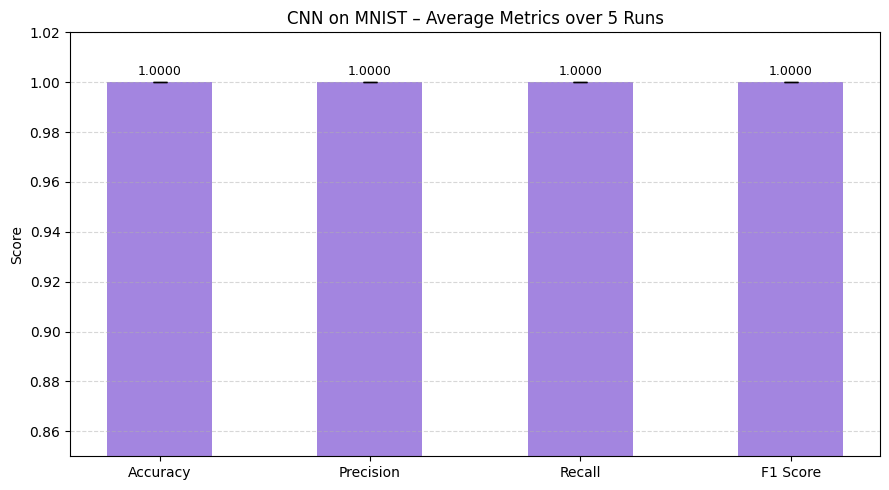

In [60]:
avg = df_results[metrics].mean()
std = df_results[metrics].std()

x     = np.arange(len(metrics))
width = 0.5

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, avg, width, yerr=std, color='mediumpurple', capsize=5, alpha=0.85)
ax.set_ylabel('Score')
ax.set_title('CNN on MNIST – Average Metrics over 5 Runs')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

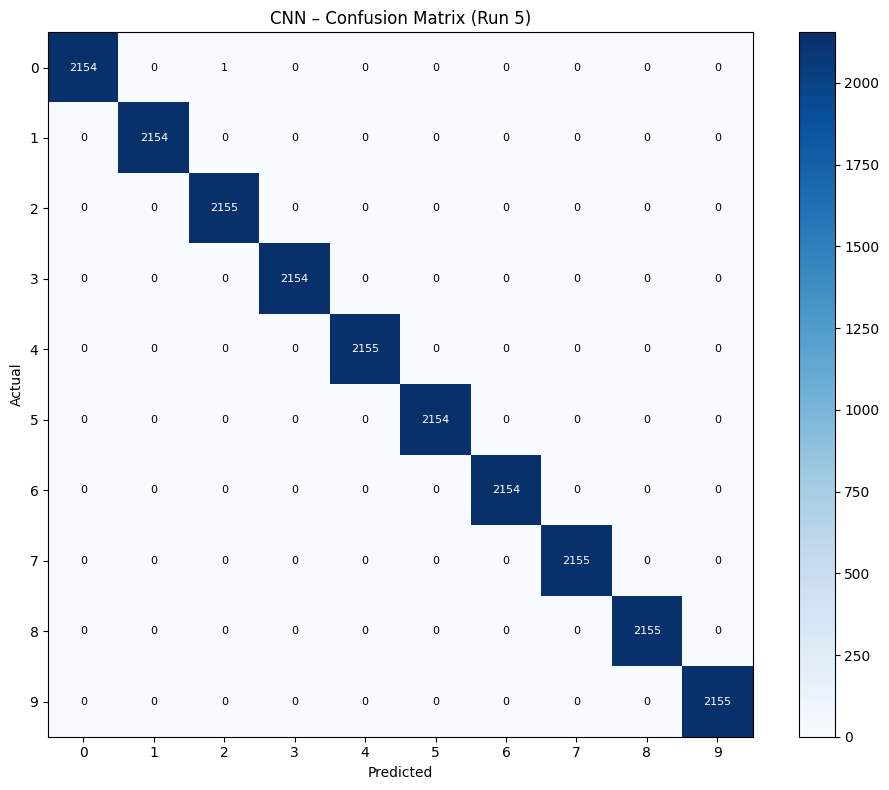

In [61]:
cm  = confusion_matrix(y_test_last, y_pred_last)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
ax.set_title('CNN – Confusion Matrix (Run 5)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [62]:
print("===== CNN – Classification Report (Run 5) =====")
print(classification_report(y_test_last, y_pred_last,
                             target_names=[str(i) for i in range(10)]))

===== CNN – Classification Report (Run 5) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2155
           1       1.00      1.00      1.00      2154
           2       1.00      1.00      1.00      2155
           3       1.00      1.00      1.00      2154
           4       1.00      1.00      1.00      2155
           5       1.00      1.00      1.00      2154
           6       1.00      1.00      1.00      2154
           7       1.00      1.00      1.00      2155
           8       1.00      1.00      1.00      2155
           9       1.00      1.00      1.00      2155

    accuracy                           1.00     21546
   macro avg       1.00      1.00      1.00     21546
weighted avg       1.00      1.00      1.00     21546



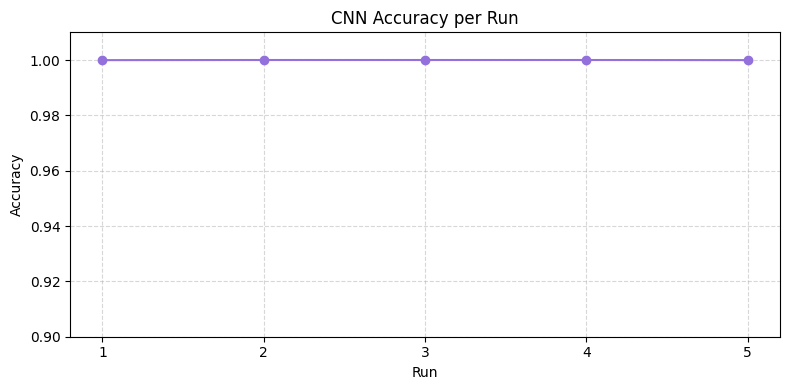

In [63]:
plt.figure(figsize=(8, 4))
plt.plot(df_results["Run"], df_results["Accuracy"], 'o-', color='mediumpurple')
plt.xlabel('Run'); plt.ylabel('Accuracy')
plt.title('CNN Accuracy per Run')
plt.xticks(df_results["Run"])
plt.ylim(0.90, 1.01)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

Format: PNG
Mode: RGBA
Size: (28, 28)
Array shape: (28, 28, 4)
Min: 0 Max: 255


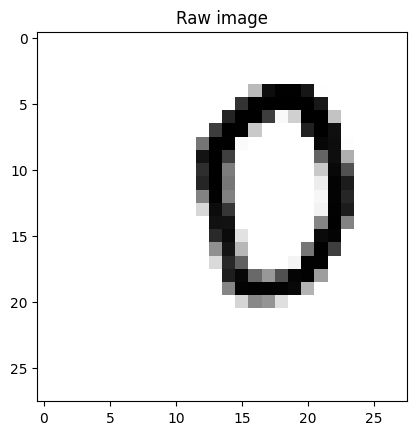

In [64]:
from PIL import Image
import os
import numpy as np

# Load one raw image without any conversion
folder = r"C:\Users\bilsr\OneDrive\Desktop\New folder\archive\dataset\0\0"
first_image = os.listdir(folder)[0]
fpath = os.path.join(folder, first_image)

img_raw = Image.open(fpath)
print("Format:", img_raw.format)
print("Mode:", img_raw.mode)
print("Size:", img_raw.size)

arr = np.array(img_raw)
print("Array shape:", arr.shape)
print("Min:", arr.min(), "Max:", arr.max())

plt.imshow(arr)
plt.title("Raw image")
plt.show()